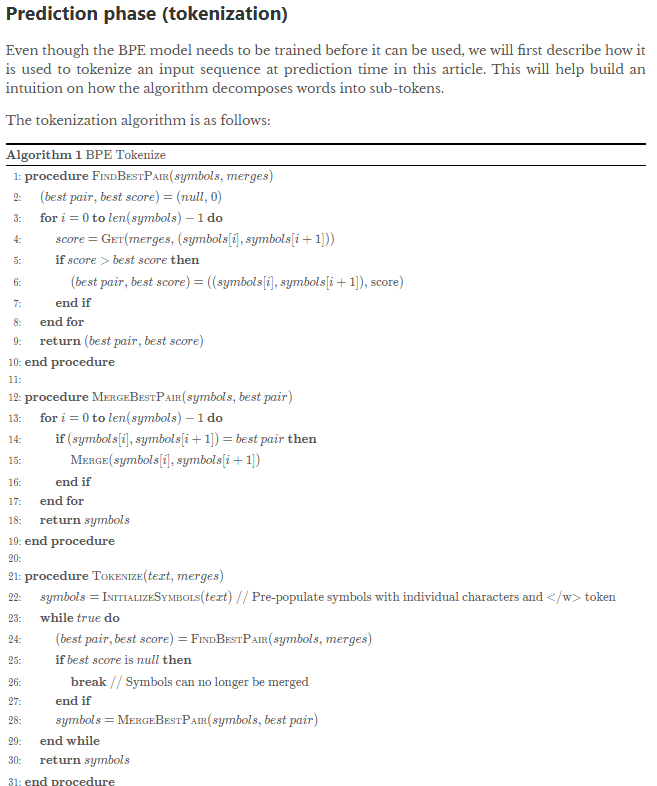

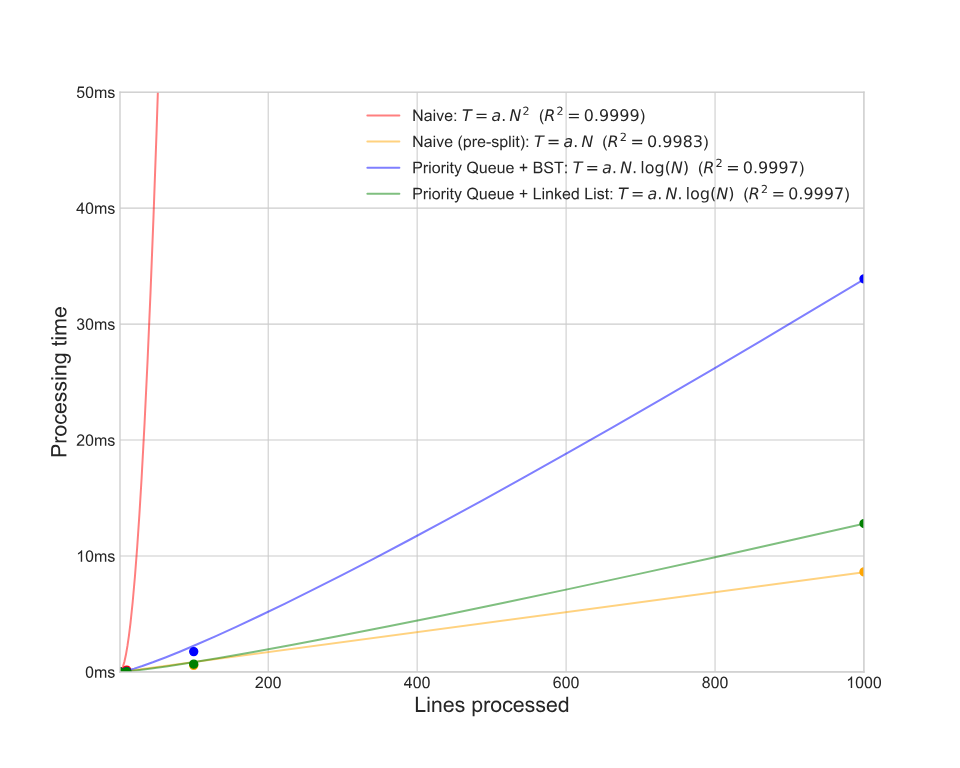

https://guillaume-be.github.io/2021-09-16/byte_pair_encoding

In [ ]:
# BPE Algorihtm

import re
from collections import defaultdict

def get_stats(vocab):
    """
    Given a vocabulary (dictionary mapping words to frequency counts), returns a 
    dictionary of tuples representing the frequency count of pairs of characters 
    in the vocabulary.
    """
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols)-1):
            pairs[symbols[i],symbols[i+1]] += freq
    return pairs

def merge_vocab(pair, v_in):
    """
    Given a pair of characters and a vocabulary, returns a new vocabulary with the 
    pair of characters merged together wherever they appear.
    """
    v_out = {}
    print(pair)
    bigram = re.escape(' '.join(pair))
    p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
    # print(bigram)
    # print(p)
    for word in v_in:
        w_out = p.sub(''.join(pair), word)
        v_out[w_out] = v_in[word]
    return v_out

def get_vocab(data):
    """
    Given a list of strings, returns a dictionary of words mapping to their frequency 
    count in the data.
    """
    vocab = defaultdict(int)
    for line in data:
        for word in line.split():
            vocab[' '.join(list(word)) + ' </w>'] += 1
    return vocab

def byte_pair_encoding(data, n):
    """
    Given a list of strings and an integer n, returns a list of n merged pairs
    of characters found in the vocabulary of the input data.
    """
    vocab = get_vocab(data)
    print(vocab)
    for i in range(n):
        pairs = get_stats(vocab)

        best = max(pairs, key=pairs.get)
        # print(best)
        vocab = merge_vocab(best, vocab)
        # break
    return vocab

# Example usage:
corpus = '''Tokenization is the process of breaking down 
a sequence of text into smaller units called tokens,
which can be words, phrases, or even individual characters.
Tokenization is often the first step in natural languages processing tasks 
such as text classification, named entity recognition, and sentiment analysis.
The resulting tokens are typically used as input to further processing steps,
such as vectorization, where the tokens are converted
into numerical representations for machine learning models to use.'''
data = corpus.split('.') # to convert it to sentences

n = 230
bpe_pairs = byte_pair_encoding(data, n)
bpe_pairs


In [2]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

def merge(ids, pair, idx):
  newids = []
  i = 0
  while i < len(ids):
    if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
      newids.append(idx)
      i += 2
    else:
      newids.append(ids[i])
      i += 1
  return newids

# ---
text = "Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception."
tokens = text.encode("utf-8") # raw bytes
tokens = list(map(int, tokens)) # convert to a list of integers in range 0..255 for convenience

vocab_size = 276 # the desired final vocabulary size
num_merges = vocab_size - 256
ids = list(tokens) # copy so we don't destroy the original list

merges = {} # (int, int) -> int
for i in range(num_merges):
  stats = get_stats(ids)
  print(stats)
  pair = max(stats, key=stats.get)
  idx = 256 + i
  print(f"merging {pair} into a new token {idx}")
  ids = merge(ids, pair, idx)
  merges[pair] = idx
  break

{(239, 188): 1, (188, 181): 1, (181, 239): 1, (239, 189): 6, (189, 142): 1, (142, 239): 1, (189, 137): 1, (137, 239): 1, (189, 131): 1, (131, 239): 1, (189, 143): 1, (143, 239): 1, (189, 132): 1, (132, 239): 1, (189, 133): 1, (133, 33): 1, (33, 32): 2, (32, 240): 3, (240, 159): 15, (159, 133): 7, (133, 164): 1, (164, 240): 1, (133, 157): 1, (157, 240): 1, (133, 152): 1, (152, 240): 1, (133, 146): 1, (146, 240): 1, (133, 158): 1, (158, 240): 1, (133, 147): 1, (147, 240): 1, (133, 148): 1, (148, 226): 1, (226, 128): 12, (128, 189): 1, (189, 32): 1, (159, 135): 7, (135, 186): 1, (186, 226): 1, (128, 140): 6, (140, 240): 6, (135, 179): 1, (179, 226): 1, (135, 174): 1, (174, 226): 1, (135, 168): 1, (168, 226): 1, (135, 180): 1, (180, 226): 1, (135, 169): 1, (169, 226): 1, (135, 170): 1, (170, 33): 1, (159, 152): 1, (152, 132): 1, (132, 32): 1, (32, 84): 1, (84, 104): 1, (104, 101): 6, (101, 32): 20, (32, 118): 1, (118, 101): 3, (101, 114): 6, (114, 121): 2, (121, 32): 2, (32, 110): 2, (110,

- https://github.com/karpathy/minbpe
- https://github.com/guillaume-be/bpe-example/blob/main/sentencepiece/sentencepiece_model.proto